# PacifyIQ — 02 · Exploratory Data Analysis (Phase 3)

Answers seven questions, each attached to a decision that affects Phase 4+.

1. What kinds of customer problems exist?
2. Which are most common?
3. Which generate the most negative sentiment?
4. Which are urgent?
5. Are categories imbalanced?
6. What does the language of each issue type look like?
7. What patterns influence model / RAG / agent design?

In [2]:
import sys, pathlib

# Locate the project root by walking up until we find src/.
# Works whether the kernel starts in notebooks/ or the workspace root.
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("interpreter: ", sys.executable)
print("project root:", ROOT)

import pandas as pd
from src.eda import loaders, plots, text_stats, audit

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plots.setup()

interpreter:  c:\DS-AI-Spiced\PacifyIQ_GenAI_Customer_Support_Platform\.venv\Scripts\python.exe
project root: c:\DS-AI-Spiced\PacifyIQ_GenAI_Customer_Support_Platform\pacifyiq\pacifyiq


In [3]:
tickets = loaders.load_tickets()
train   = loaders.load_intent_train()
test    = loaders.load_intent_test()
corpus  = loaders.load_corpus()
print(f"{len(tickets):,} tickets | {len(train):,} train | {len(test)} test | {len(corpus)} pages")

11,905 tickets | 2,200 train | 142 test | 47 pages


## Q1 & Q2 — What problems exist, and which dominate?

In [4]:
profile = (tickets.groupby("intent", observed=True)
    .agg(tickets=("ticket_id","size"),
         escalation_pct=("escalated", lambda s: round(100*s.mean(),1)),
         negative_pct=("sentiment", lambda s: round(100*(s=="negative").mean(),1)),
         high_priority_pct=("priority", lambda s: round(100*(s=="high").mean(),1)))
    .sort_values("tickets", ascending=False))
profile["share_pct"] = (100*profile["tickets"]/profile["tickets"].sum()).round(1)
profile

,tickets,escalation_pct,negative_pct,high_priority_pct,share_pct
intent,,,,,
order_tracking,2231,12.7,27.4,20.3,18.7
return_policy_question,1906,12.6,11.8,17.3,16.0
return_refund_request,1420,71.1,51.7,24.9,11.9
shipping_delivery,1409,17.2,22.1,20.2,11.8
product_information,1289,15.7,5.3,16.0,10.8
technical_support,1244,37.1,40.4,22.9,10.4
warranty_claim,893,60.7,49.3,26.4,7.5
payment_issue,647,62.6,63.1,26.6,5.4
account_management,484,80.8,21.5,20.0,4.1


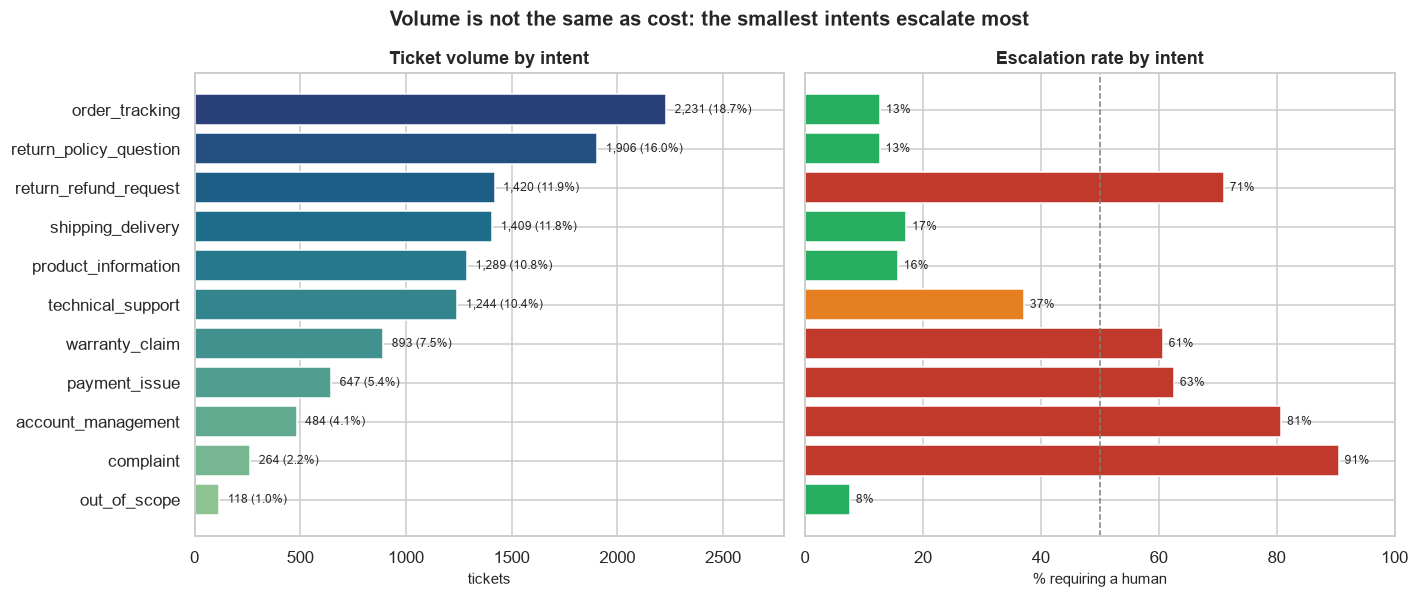

In [5]:
plots.fig_intent_distribution(tickets, save=False)

**Finding.** The top three intents are 47% of volume but escalate at 13%, 13% and 71%.
`complaint` is 2.2% of volume and escalates at 91%. Volume and operational cost point
in different directions — the deflection target should be set per intent, not globally.

## Q3 & Q4 — Negative sentiment and urgency

In [6]:
profile.sort_values("negative_pct", ascending=False)[
    ["negative_pct","high_priority_pct","escalation_pct","tickets"]]

,negative_pct,high_priority_pct,escalation_pct,tickets
intent,,,,
complaint,84.5,37.5,90.5,264
payment_issue,63.1,26.6,62.6,647
return_refund_request,51.7,24.9,71.1,1420
warranty_claim,49.3,26.4,60.7,893
technical_support,40.4,22.9,37.1,1244
order_tracking,27.4,20.3,12.7,2231
shipping_delivery,22.1,20.2,17.2,1409
account_management,21.5,20.0,80.8,484
return_policy_question,11.8,17.3,12.6,1906


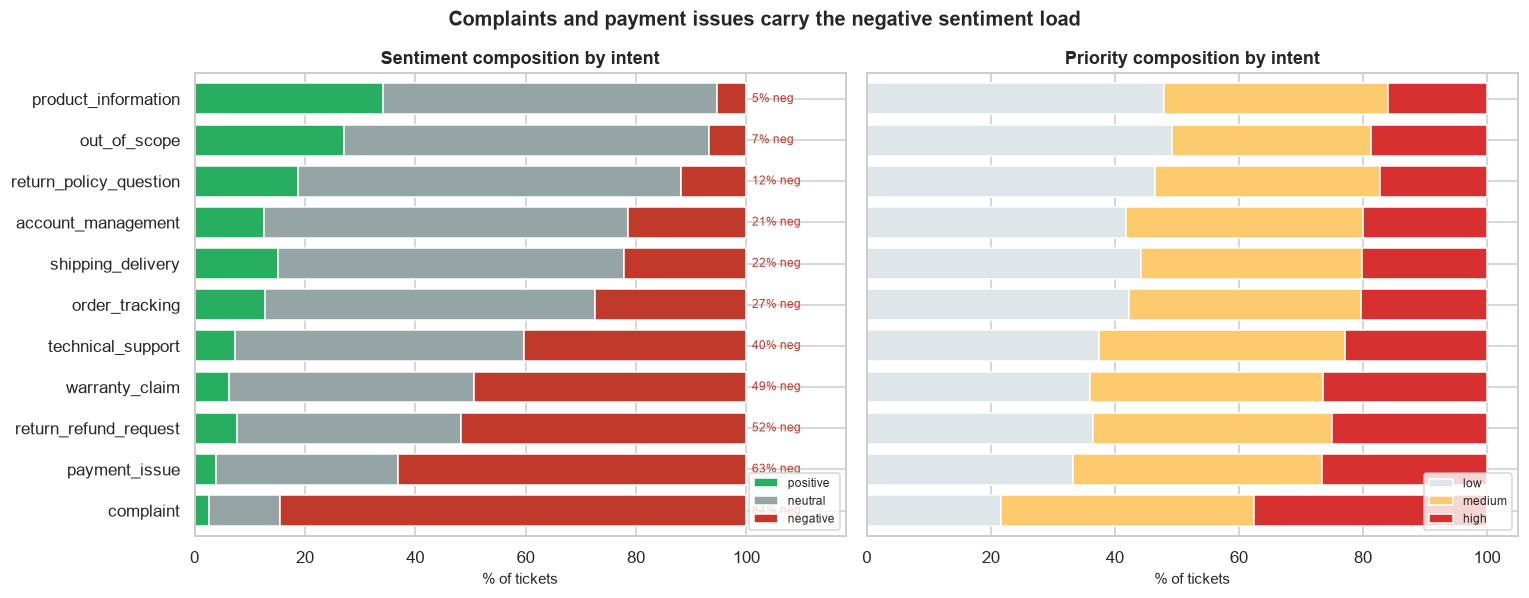

In [7]:
plots.fig_sentiment_urgency(tickets, save=False)

In [8]:
# Does negative sentiment actually predict escalation?
corr = tickets.assign(neg=(tickets["sentiment"]=="negative").astype(int))[["neg","escalated"]].corr().iloc[0,1]
print(f"correlation(negative sentiment, escalated) = {corr:.3f}")

by = tickets.groupby(["intent","sentiment"], observed=True)["escalated"].mean().unstack()*100
by.round(1)

correlation(negative sentiment, escalated) = 0.305


sentiment,negative,neutral,positive
intent,,,
order_tracking,29.6,6.3,6.7
return_policy_question,31.6,10.7,7.8
return_refund_request,75.9,65.6,67.3
product_information,29.4,14.4,16.1
shipping_delivery,34.9,13.0,8.4
technical_support,48.4,29.1,32.6
warranty_claim,63.4,58.2,57.1
payment_issue,65.9,57.0,56.0
account_management,87.5,79.6,75.4


**Finding.** Sentiment shifts escalation rate *within* every intent, but the intent
itself explains far more. This argues for sentiment as one weighted signal in the
escalation policy, not as a trigger on its own.

## Q5 — Class imbalance

In [9]:
counts = train["intent"].value_counts()
print(f"train imbalance: {counts.max()}:{counts.min()} = {counts.max()/counts.min():.1f}x")
print(f"majority-class baseline accuracy: {100*counts.max()/counts.sum():.1f}%")
print()
print(pd.DataFrame({"train": counts,
                    "train_pct": (100*counts/counts.sum()).round(1),
                    "test": test["intent"].value_counts()}))

train imbalance: 400:40 = 10.0x
majority-class baseline accuracy: 18.2%

                        train  train_pct  test
intent                                        
order_tracking            400       18.2    13
return_policy_question    300       13.6    17
return_refund_request     280       12.7    19
product_information       260       11.8    12
shipping_delivery         240       10.9     5
technical_support         220       10.0    13
warranty_claim            180        8.2    16
payment_issue             130        5.9    15
account_management         90        4.1     5
complaint                  60        2.7    12
out_of_scope               40        1.8    15


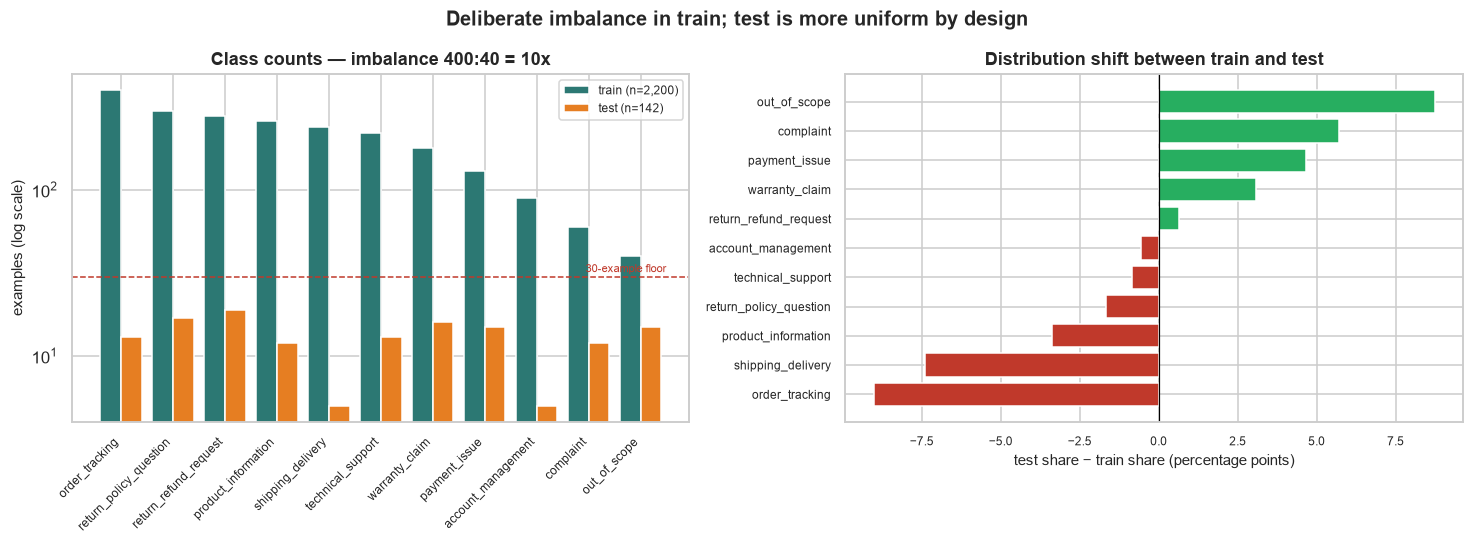

In [10]:
plots.fig_class_imbalance(train, test, save=False)

**Decision.** Macro-F1, not accuracy. A model predicting `order_tracking` for
everything scores 18.2% accuracy and is useless. Use `class_weight='balanced'` and
stratified splits.

## Q6 — What does the language look like?

In [11]:
tr_feats = pd.concat([train.reset_index(drop=True),
                      text_stats.length_features(train["text"]).drop(columns=["text"]),
                      text_stats.lexicon_features(train["text"])], axis=1)
te_feats = pd.concat([test.reset_index(drop=True),
                      text_stats.length_features(test["text"]).drop(columns=["text"]),
                      text_stats.lexicon_features(test["text"])], axis=1)

print("TRAIN"); print(text_stats.length_summary(tr_feats))
print("\nTEST"); print(text_stats.length_summary(te_feats))

TRAIN
       n_chars  n_words  n_sentences
count   2200.0   2200.0       2200.0
mean      36.7      6.6          1.0
std        9.8      2.0          0.1
min        2.0      1.0          1.0
25%       30.0      5.0          1.0
50%       36.0      6.0          1.0
75%       43.0      8.0          1.0
max       71.0     13.0          2.0

TEST
       n_chars  n_words  n_sentences
count    142.0    142.0        142.0
mean      52.9     10.2          1.2
std       45.6      8.7          0.8
min        1.0      1.0          1.0
25%       29.2      6.0          1.0
50%       42.0      8.0          1.0
75%       60.0     12.0          1.0
max      335.0     66.0          6.0


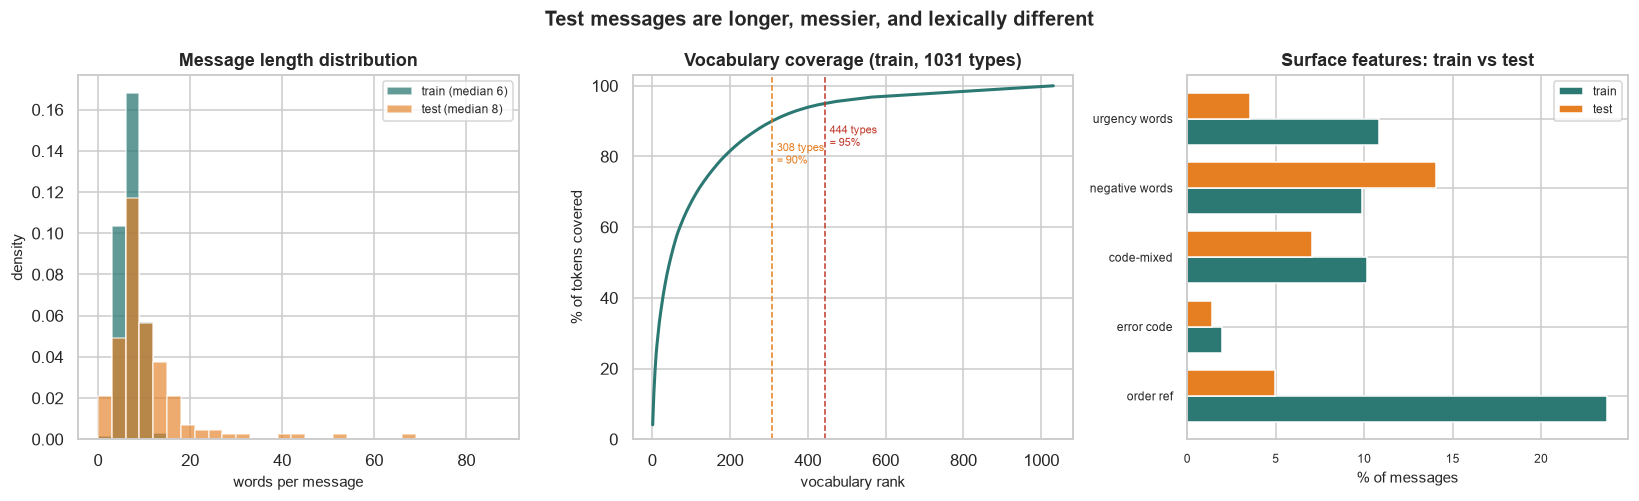

In [12]:
plots.fig_text_characteristics(tr_feats, te_feats, save=False)

### Most frequent n-grams

In [13]:
for n, label in [(1,"unigrams"), (2,"bigrams"), (3,"trigrams")]:
    print(f"--- {label} ---")
    print(text_stats.top_ngrams(train["text"], n=n, top=10).to_string(index=False))
    print()

--- unigrams ---
 ngram  count
     i    598
    my    470
    is    456
   the    354
return    338
 order    332
    do    264
   for    257
please    256
    to    204

--- bigrams ---
    ngram  count
     do i    146
    can i    111
   i want    109
to return    107
   do you     92
 my order     79
   is the     79
   how do     75
    is my     70
  want to     70

--- trigrams ---
            ngram  count
         how do i     74
        i want to     70
   want to return     55
vision 27 monitor     39
      is my order     37
     can i return     37
      where is my     36
        i need to     33
    my money back     29
      if i return     25



### Terms that distinguish each intent

In [14]:
dist = text_stats.distinctive_terms(train["text"], train["intent"], top=6)
for intent in loaders.INTENT_ORDER:
    sub = dist[dist["intent"]==intent]
    if len(sub):
        print(f"{intent:24s} {', '.join(sub['term'])}")

order_tracking           order, delivery, my order, when, for, my
return_policy_question   return, i, i return, do i, do, the
return_refund_request    i, want, refund, i want, return, to return
product_information      the, does, probook, does the, of, have
shipping_delivery        delivery, you, do you, do, can, shipping
technical_support        my, laptop, getting, how do, keeps, do i
warranty_claim           warranty, months, claim, is, my, period for
payment_issue            my, invoice, for order, card, was, emi
account_management       my, account, my account, delete, how do, i
complaint                this, service, to, bahut, this is, a
out_of_scope             ok, me a, what, me, you, who


### Vocabulary and drift

In [15]:
for name, texts in [("train", train["text"]), ("test", test["text"])]:
    s = text_stats.vocabulary_stats(texts)
    print(f"{name}: vocab={s['vocab_size']}, TTR={s['type_token_ratio']}, "
          f"hapax={s['hapax_pct']}%, 90% coverage at {s['types_for_90pct_coverage']} types")

print()
drift = text_stats.vocabulary_drift(train["text"], test["text"])
for k, v in drift.items():
    if k != "example_oov":
        print(f"  {k:24s} {v}")
print("\nexample OOV terms:", drift["example_oov"][:15])

train: vocab=1031, TTR=0.0707, hapax=45.7%, 90% coverage at 308 types
test: vocab=538, TTR=0.3698, hapax=65.8%, 90% coverage at 393 types

  train_vocab              1031
  test_vocab               538
  oov_types                264
  oov_type_rate_pct        49.1
  oov_token_rate_pct       22.6
  shared_vocab             274

example OOV terms: ['-', '19', '40k', '5-7', '560001', '5th', '7', '90k', '99999', 'aa', 'access', 'accidental', 'accounts', 'air', 'already']


### Template detection

In [16]:
print("train:", text_stats.template_score(train["text"]))
print("test: ", text_stats.template_score(test["text"]))
print()
text_stats.detect_templates(train["text"]).head(10)

train: {'n_messages': 2200, 'n_unique_skeletons': 1847, 'messages_sharing_skeleton': 591, 'template_rate_pct': 26.9}
test:  {'n_messages': 142, 'n_unique_skeletons': 142, 'messages_sharing_skeleton': 0, 'template_rate_pct': 0.0}



,skeleton,n_variants
0,when will pac-<NUM> arrive,9
1,delivery date for pac-<NUM>?,8
2,i want to return pac-<NUM> and buy something e...,7
3,any update on pac-<NUM>,7
4,initiate return for pac-<NUM>,7
5,track order pac-<NUM>,6
6,order pac-<NUM> kahan hai,6
7,i want my money back for pac-<NUM>,6
8,where is my order pac-<NUM>,6
9,pac-<NUM> kab tak aayega,6


**Finding.** 26.9% of training messages share a skeleton with another message;
the test set has 0%. Combined with a 22.6% OOV token rate, this quantifies the gap
between templated training data and hand-written messages — and predicts a
substantial macro-F1 drop in Phase 4.

### Sentiment language

In [17]:
lex = tr_feats.groupby("intent", observed=True)[["n_negative","n_positive","n_urgency","n_codemix"]].mean().round(2)
lex["polarity"] = (lex["n_positive"] - lex["n_negative"]).round(2)
lex.sort_values("polarity")

,n_negative,n_positive,n_urgency,n_codemix,polarity
intent,,,,,
complaint,0.80,0.15,0.30,0.18,-0.65
warranty_claim,0.28,0.12,0.05,0.23,-0.16
shipping_delivery,0.18,0.15,0.25,0.39,-0.03
account_management,0.00,0.09,0.08,0.78,0.09
out_of_scope,0.00,0.10,0.05,0.20,0.10
technical_support,0.00,0.11,0.12,0.37,0.11
order_tracking,0.04,0.15,0.16,0.48,0.11
return_policy_question,0.04,0.15,0.10,0.69,0.11
return_refund_request,0.18,0.29,0.05,0.32,0.11


## Q7 — Patterns that influence design

### Class separability

In [18]:
overlap = text_stats.class_lexical_overlap(train["text"], train["intent"])
overlap.head(10)

,intent_a,intent_b,jaccard,shared_terms
0,order_tracking,return_refund_request,0.250,"12345, for, my, order, pac-2026-12345, pac-202..."
1,return_policy_question,shipping_delivery,0.176,"can, do, i, is, to, what"
2,account_management,shipping_delivery,0.176,"do, how, i, my, to, you"
3,order_tracking,payment_issue,0.143,"for, is, my, order, where"
4,shipping_delivery,technical_support,0.143,"do, how, i, is, my"
5,account_management,technical_support,0.111,"do, how, i, my"
6,account_management,complaint,0.111,"hai, i, to, you"
7,complaint,shipping_delivery,0.111,"i, is, to, you"
8,payment_issue,return_refund_request,0.111,"for, i, my, order"
9,return_policy_question,return_refund_request,0.111,"for, i, return, to"


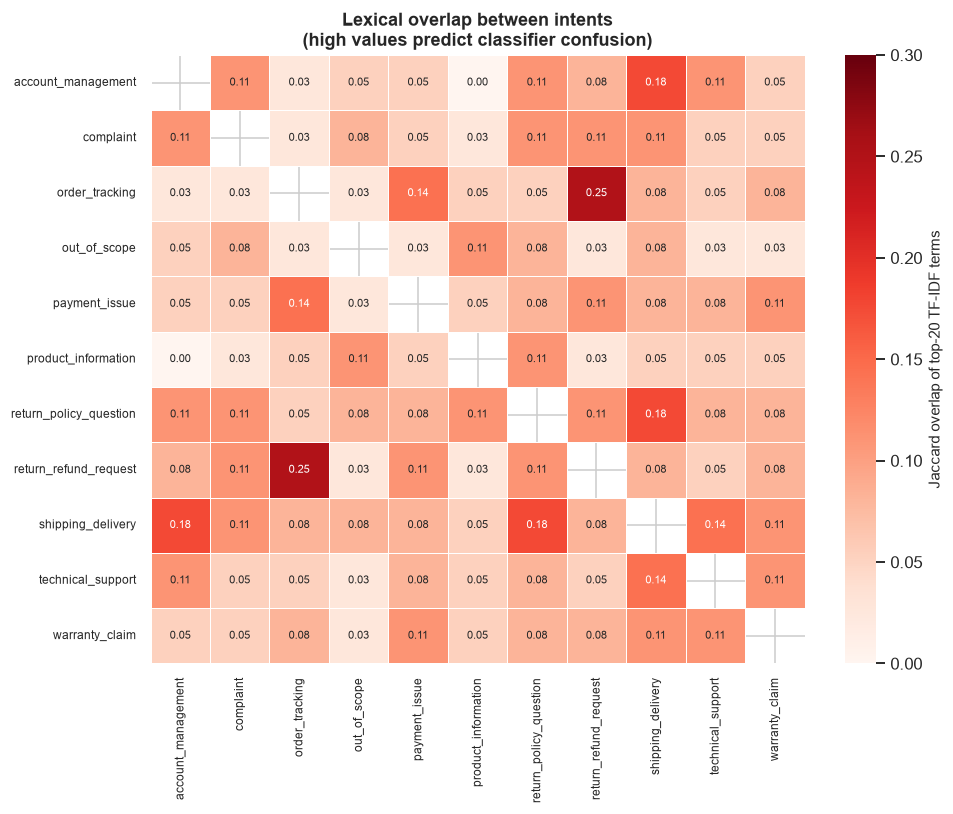

In [19]:
plots.fig_class_overlap(overlap, save=False)

**Finding.** `order_tracking` ↔ `return_refund_request` share J=0.25, driven entirely
by order-reference tokens. Order IDs carry no intent signal and should be masked to a
placeholder before vectorising.

### Temporal structure

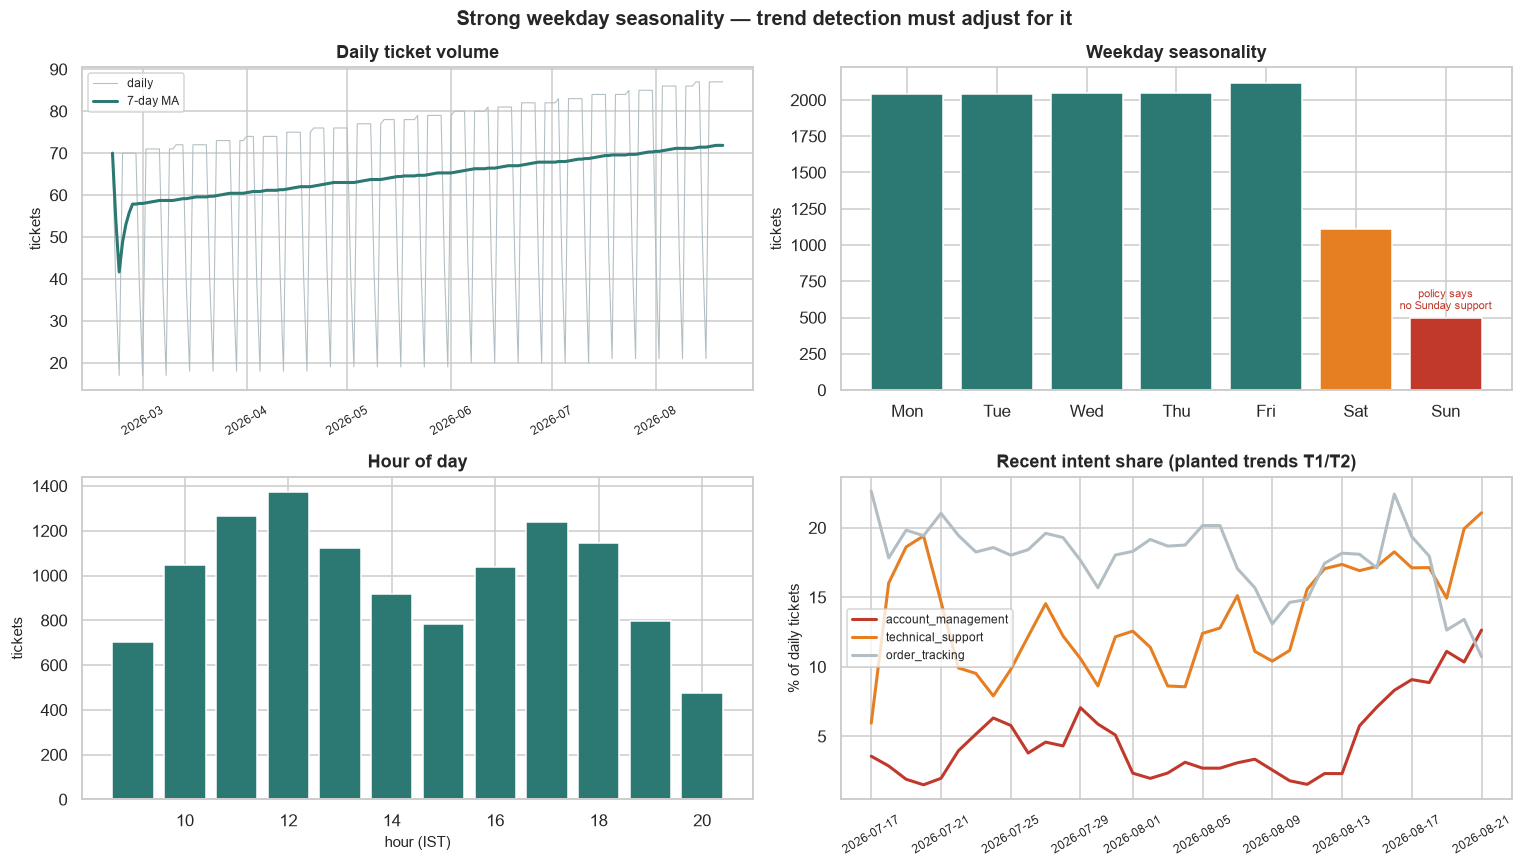

In [20]:
plots.fig_temporal(tickets, save=False)

In [21]:
dow = tickets.groupby("weekday").size()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
print((dow.reindex(order) / dow.reindex(order).max()).round(2))

weekday
Monday       0.96
Tuesday      0.96
Wednesday    0.96
Thursday     0.97
Friday       1.00
Saturday     0.52
Sunday       0.23
dtype: float64


**Finding.** Saturday runs at 52% of a weekday and Sunday at 23%. A naive
week-over-week trend detector will fire on day-of-week effects. Compare like-for-like
days or use a 7-day rolling baseline.

### Corpus structure

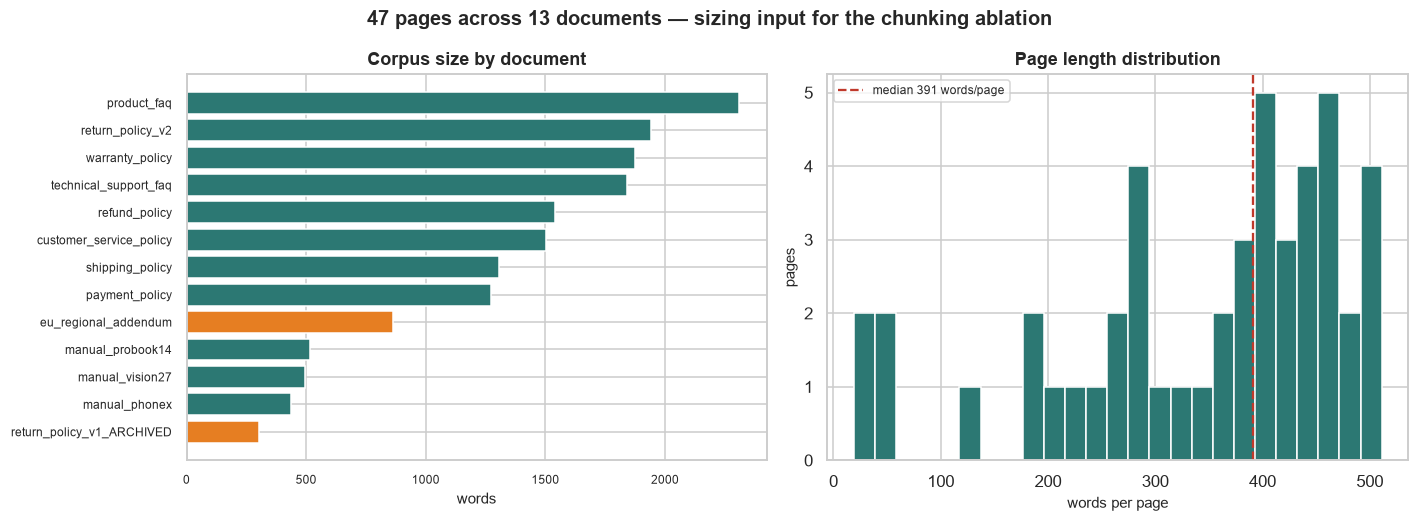

In [22]:
plots.fig_corpus(corpus, save=False)

In [23]:
per_doc = corpus.groupby("doc").agg(pages=("page","max"), words=("n_words","sum"))
per_doc["words_per_page"] = (per_doc["words"]/per_doc["pages"]).round(0)
per_doc.sort_values("words", ascending=False)

,pages,words,words_per_page
doc,,,
product_faq,6,2311,385.0
return_policy_v2,5,1942,388.0
warranty_policy,5,1873,375.0
technical_support_faq,5,1843,369.0
refund_policy,4,1542,386.0
customer_service_policy,4,1503,376.0
shipping_policy,4,1306,326.0
payment_policy,3,1274,425.0
eu_regional_addendum,3,864,288.0


In [24]:
# What chunk sizes are plausible given page lengths?
import numpy as np
wpp = corpus["n_words"]
print(f"words per page: median {wpp.median():.0f}, p25 {wpp.quantile(.25):.0f}, p75 {wpp.quantile(.75):.0f}")
print(f"approx tokens per page (x1.3): median {wpp.median()*1.3:.0f}")
print(f"\ntotal corpus: {wpp.sum():,} words ~ {wpp.sum()*1.3:,.0f} tokens")
for cs in [256, 512, 1024]:
    print(f"  chunk_size={cs:5d} -> ~{wpp.sum()*1.3/cs:.0f} chunks")

words per page: median 391, p25 272, p75 448
approx tokens per page (x1.3): median 508

total corpus: 16,208 words ~ 21,070 tokens
  chunk_size=  256 -> ~82 chunks
  chunk_size=  512 -> ~41 chunks
  chunk_size= 1024 -> ~21 chunks


**Decision.** A median page is ~508 tokens, so chunk_size 512 sits at roughly one
page and 256 at half a page. The Phase 6 ablation should test 256 / 512 / 1024 —
1024 would span pages and break the page-level citation guarantee.

---

## Summary

Full write-up in `reports/eda_findings.md`. Processed outputs are in
`data/processed/` for reuse by Phase 4.